In [ ]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
# Importing the data
df = pd.read_csv("Inflation.csv", sep="|", skiprows=2, encoding="windows-1254")
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,01-Ocak,02-Şubat,03-Mart,04-Nisan,05-Mayıs,06-Haziran,07-Temmuz,08-Ağustos,09-Eylül,10-Ekim,11-Kasım,12-Aralık,Unnamed: 15
0,Tüketici Fiyat Endeksi (2003=100) Aylık Değişi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2005.0,0.55,0.02,0.26,0.71,0.92,0.10,-0.57,0.85,1.02,1.79,1.40,0.42,NaN
2,NaN,NaN,2006.0,0.75,0.22,0.27,1.34,1.88,0.34,0.85,-0.44,1.29,1.27,1.29,0.23,NaN
3,NaN,NaN,2007.0,1.00,0.43,0.92,1.21,0.50,-0.24,-0.73,0.02,1.03,1.81,1.95,0.22,NaN
4,NaN,NaN,2008.0,0.80,1.29,0.96,1.68,1.49,-0.36,0.58,-0.24,0.45,2.60,0.83,-0.41,NaN


In [ ]:
# First row is not a header, remove it (leave only rows containing data)
df = df.iloc[1:]

In [ ]:
# Manually name the columns
aylar = ['Yıl', 'Ocak', 'Şubat', 'Mart', 'Nisan', 'Mayıs', 'Haziran',
         'Temmuz', 'Ağustos', 'Eylül', 'Ekim', 'Kasım', 'Aralık']
df.columns = ['Unnamed1', 'Unnamed2', 'Yıl'] + aylar[1:] + ['UnnamedSon']

In [ ]:
# Remove unnecessary columns
df = df.drop(columns=['Unnamed1', 'Unnamed2', 'UnnamedSon'])

In [ ]:
# Skip rows with NaN
df = df[df['Yıl'].notna()]

In [ ]:
# Convert year column to number
df['Yıl'] = df['Yıl'].astype(int)

In [ ]:
# Pivot to long format
df_long = df.melt(id_vars='Yıl', var_name='Ay', value_name='Degisim')

In [ ]:
# Create date column
ay_dict = {
    'Ocak': '01', 'Şubat': '02', 'Mart': '03', 'Nisan': '04', 'Mayıs': '05', 'Haziran': '06',
    'Temmuz': '07', 'Ağustos': '08', 'Eylül': '09', 'Ekim': '10', 'Kasım': '11', 'Aralık': '12'
}
df_long['Tarih'] = pd.to_datetime(df_long['Yıl'].astype(str) + '-' + df_long['Ay'].map(ay_dict))

In [ ]:
# Finally, sort and index
df_long = df_long.sort_values('Tarih').reset_index(drop=True)

In [ ]:
# Let's take a look
print(df_long.head(12))  # ilk yılın verileri

     Yıl       Ay  Degisim      Tarih
0   2005     Ocak     0.55 2005-01-01
1   2005    Şubat     0.02 2005-02-01
2   2005     Mart     0.26 2005-03-01
3   2005    Nisan     0.71 2005-04-01
4   2005    Mayıs     0.92 2005-05-01
5   2005  Haziran     0.10 2005-06-01
6   2005   Temmuz    -0.57 2005-07-01
7   2005  Ağustos     0.85 2005-08-01
8   2005    Eylül     1.02 2005-09-01
9   2005     Ekim     1.79 2005-10-01
10  2005    Kasım     1.40 2005-11-01
11  2005   Aralık     0.42 2005-12-01


In [ ]:
# Let's keep the months directly in Turkish
aylar = df.columns[1:]

In [ ]:
# A dictionary that converts month names into numerical data
aylar_dict = {
    'Ocak': '01', 'Şubat': '02', 'Mart': '03', 'Nisan': '04', 'Mayıs': '05', 'Haziran': '06',
    'Temmuz': '07', 'Ağustos': '08', 'Eylül': '09', 'Ekim': '10', 'Kasım': '11', 'Aralık': '12'
}

In [ ]:
# New DataFrame containing Date and Change data
dates = []
degisim_values = []

# Let's loop through the DataFrame and sort the months and values ​​for each year
for year in df['Yıl']:
    for month in aylar:
        # Convert Turkish month name to numeric format
        month_num = aylar_dict[month]
        # Create date format
        dates.append(f'{year}-{month_num}-01')
        degisim_values.append(df.loc[df['Yıl'] == year, month].values[0])

In [ ]:
# Creating a new DataFrame
df_tarih_degisim = pd.DataFrame({
    'Tarih': pd.to_datetime(dates, format='%Y-%m-%d'),
    'Degisim': degisim_values
})

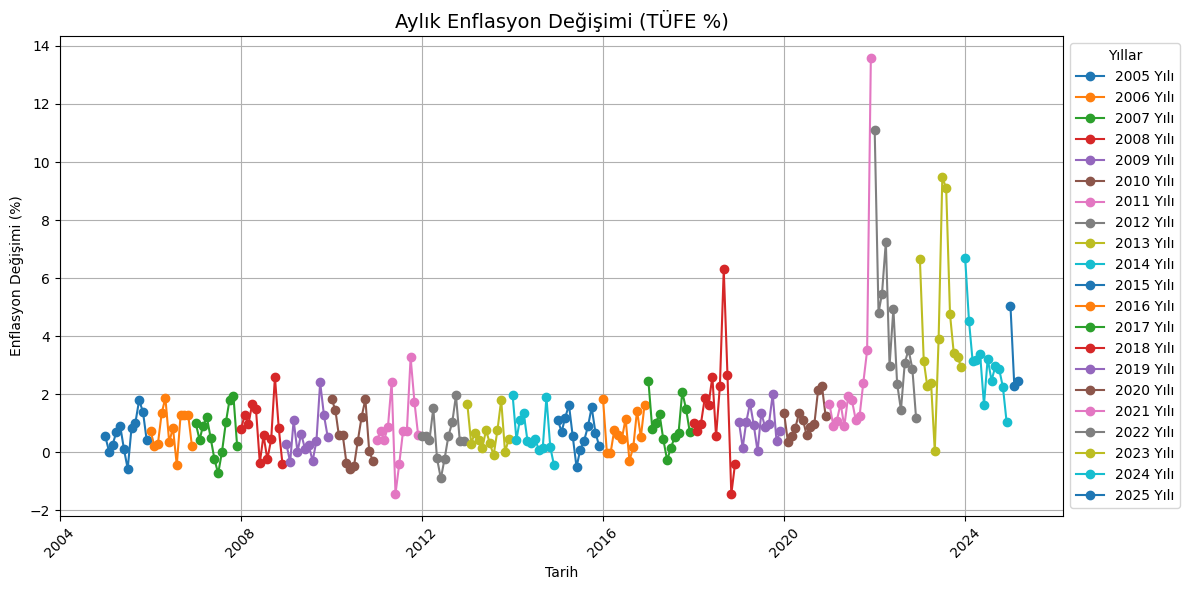

In [ ]:
# Monthly Inflation Change Graph
plt.figure(figsize=(12, 6))
for year in df['Yıl'].unique():
    yearly_data = df_tarih_degisim[df_tarih_degisim['Tarih'].dt.year == year]
    plt.plot(yearly_data['Tarih'], yearly_data['Degisim'], marker='o', linestyle='-', label=f'{year} Yılı')

plt.title("Aylık Enflasyon Değişimi (TÜFE %)", fontsize=14)
plt.xlabel('Tarih')
plt.ylabel('Enflasyon Değişimi (%)')
plt.legend(title="Yıllar", loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

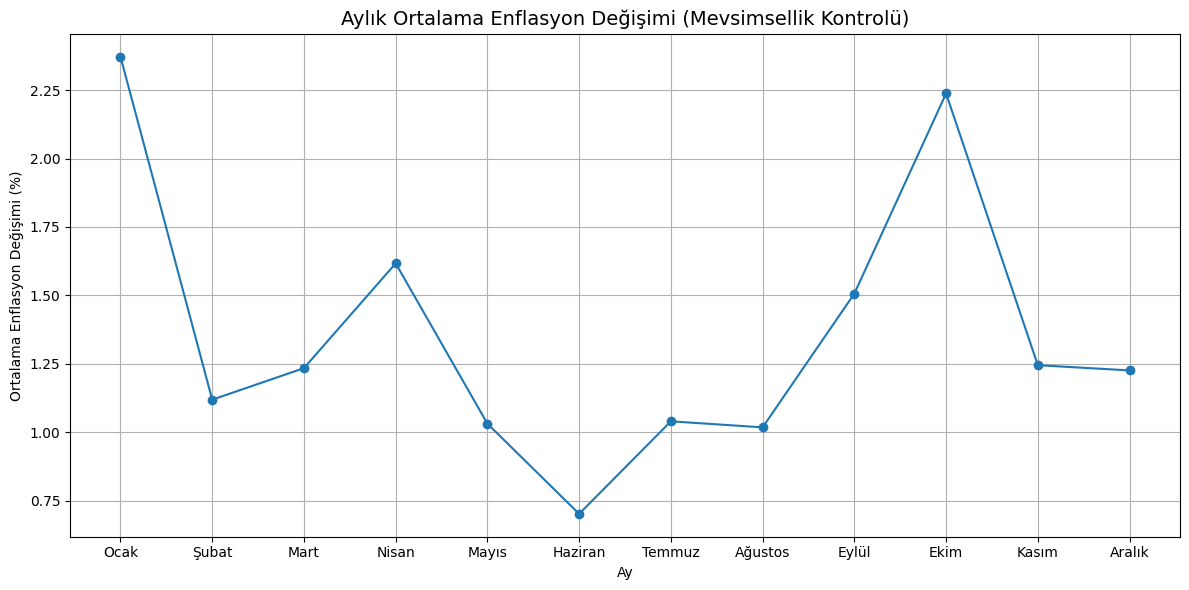

In [ ]:
# Monthly Average Change Calculation
df_tarih_degisim['Ay'] = df_tarih_degisim['Tarih'].dt.month

# Calculate the average change for each month
df_monthly_avg = df_tarih_degisim.groupby('Ay').agg({'Degisim': 'mean'}).reset_index()

# Monthly Average Change Graph
plt.figure(figsize=(12, 6))
plt.plot(df_monthly_avg['Ay'], df_monthly_avg['Degisim'], marker='o', linestyle='-', color='tab:blue')
plt.title("Aylık Ortalama Enflasyon Değişimi (Mevsimsellik Kontrolü)", fontsize=14)
plt.xlabel('Ay')
plt.ylabel('Ortalama Enflasyon Değişimi (%)')
plt.xticks(df_monthly_avg['Ay'], ['Ocak', 'Şubat', 'Mart', 'Nisan', 'Mayıs', 'Haziran', 'Temmuz', 'Ağustos', 'Eylül', 'Ekim', 'Kasım', 'Aralık'])
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Convert date column to datetime format
df_tarih_degisim['Tarih'] = pd.to_datetime(df_tarih_degisim['Tarih'], format='%Y-%m-%d')

# Let's sort the data by the 'Date' column
df_tarih_degisim = df_tarih_degisim.sort_values('Tarih')

# Let's convert the data to time series format
ts = df_tarih_degisim.set_index('Tarih')['Degisim']

# Check the first few rows of data
ts.head()


Tarih
2005-01-01    0.55
2005-02-01    0.02
2005-03-01    0.26
2005-04-01    0.71
2005-05-01    0.92
Name: Degisim, dtype: float64

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Setting Up the ARIMA Model (with initial parameters p=1, d=1, q=1)
model = ARIMA(ts, order=(1, 1, 1))
model_fit = model.fit()

# Making predictions for the next 12 months
forecast = model_fit.forecast(steps=12)

# Printing prediction results
print(forecast)


2026-01-01    3.219532
2026-02-01    3.219652
2026-03-01    3.219706
2026-04-01    3.219729
2026-05-01    3.219740
2026-06-01    3.219744
2026-07-01    3.219746
2026-08-01    3.219747
2026-09-01    3.219748
2026-10-01    3.219748
2026-11-01    3.219748
2026-12-01    3.219748
Freq: MS, Name: predicted_mean, dtype: float64


c:\Users\mahsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mahsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mahsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


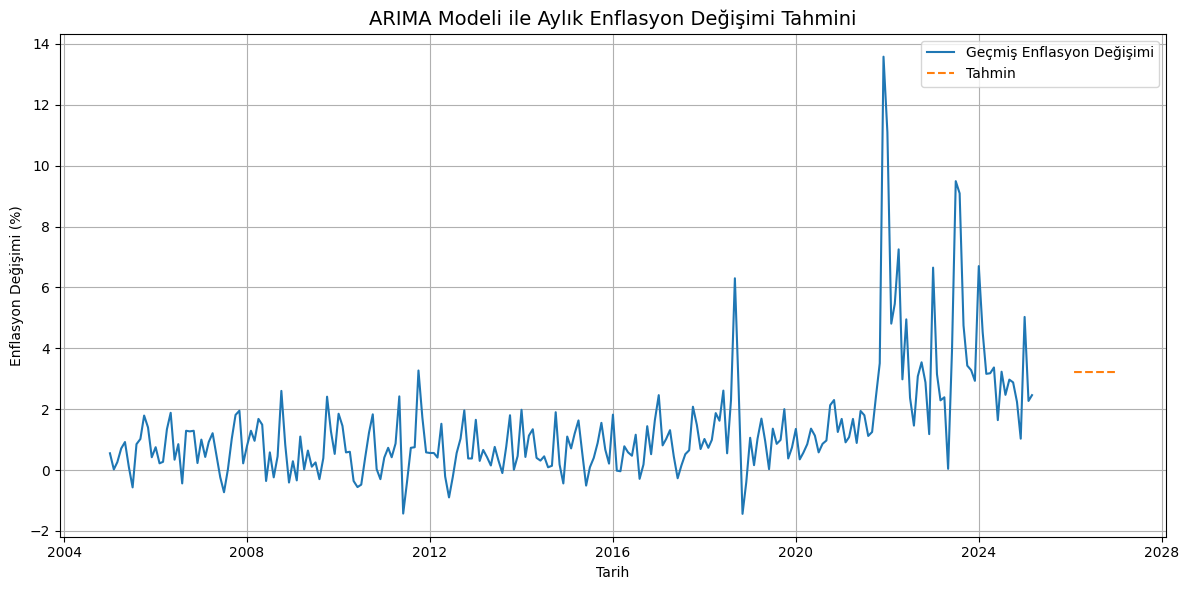

In [ ]:
# Showing the next 12 months forecast on a chart
plt.figure(figsize=(12, 6))
plt.plot(ts, label='Geçmiş Enflasyon Değişimi')
plt.plot(pd.date_range(ts.index[-1], periods=13, freq='M')[1:], forecast, label='Tahmin', linestyle='--')
plt.title("ARIMA Modeli ile Aylık Enflasyon Değişimi Tahmini", fontsize=14)
plt.xlabel('Tarih')
plt.ylabel('Enflasyon Değişimi (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# NaN check for predictions only (because there is no test set)
print("Tahminlerde NaN var mı?", pd.Series(forecast).isna().sum())


Tahminlerde NaN var mı? 0


In [ ]:
# All time series data: ts
train = ts[:-12] 
test = ts[-12:]    

# Build the model with only training data
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# Make a prediction (as much as test data)
forecast = model_fit.forecast(steps=12)

# NaN check
print("Test verisinde NaN var mı?", test.isna().sum())
print("Tahminlerde NaN var mı?", pd.Series(forecast).isna().sum())


Test verisinde NaN var mı? 9
Tahminlerde NaN var mı? 0


c:\Users\mahsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mahsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mahsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
import numpy as np
import pandas as pd

# Remove NaN values ​​from test data
test_clean = test.dropna()

# Remove NaN values ​​in Forecast
forecast_clean = forecast[~np.isnan(forecast)]

# Bringing both data sets to the same length (if there is still NaN)
forecast_clean = forecast_clean[:len(test_clean)]

# Calculate error metrics with cleaned data
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test_clean, forecast_clean)
rmse = np.sqrt(mean_squared_error(test_clean, forecast_clean))

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")


MAE: 1.2562, RMSE: 1.6926
